In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay, classification_report

In [8]:
# TO THINK ABOUT PROB WNAT TO BE MORE OK WITH FALSE ALARMS
# When trying different models, pick model that is one standard error away from best and simplest

df = pd.read_csv("distributed_system_architecture_stress_dataset.csv")

In [9]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train_df = pd.read_csv("y_train.csv")
y_test_df = pd.read_csv("y_test.csv")
y_train = y_train_df["system_state"]
y_test = y_test_df["system_state"]

In [ ]:
categorical_cols = ["architecture_type", "deployment_type", "communication_type"]
numerical_cols = X_train.columns.drop(categorical_cols)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

In [11]:
basic_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [12]:
basic_pipeline.fit(X_train, y_train)
lr_y_pred = basic_pipeline.predict(X_test)

accuracy = basic_pipeline.score(X_test, y_test)
print("Test accuracy:", accuracy)

cv_scores = cross_val_score(basic_pipeline, X_train, y_train, cv=5)
print("CV mean:", cv_scores.mean())

lr_y_prob = basic_pipeline.predict_proba(X_test)
roc_auc = roc_auc_score(
    y_test,
    lr_y_prob,
    multi_class="ovr",
    average="macro"
)
print("Test ROC AUC (macro):", roc_auc)

Test accuracy: 0.98835
CV mean: 0.98858125
Test ROC AUC (macro): 0.9989439523818315


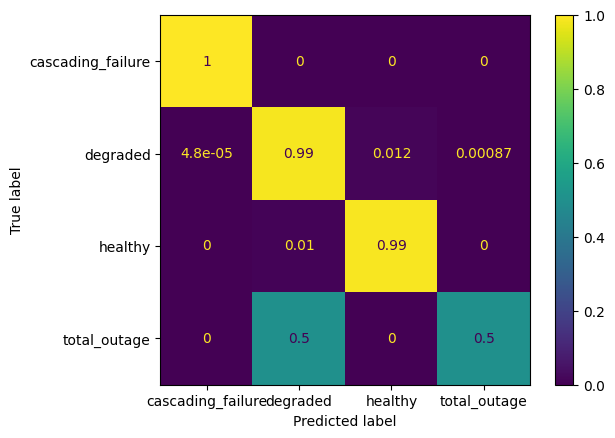

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_y_pred,
    normalize="true" 
)

In [14]:
lda_pipeline = Pipeline([
    ("prep", preprocess),
    ("model", LinearDiscriminantAnalysis())
])

Test accuracy: 0.91145
                   precision    recall  f1-score   support

cascading_failure       1.00      1.00      1.00       245
         degraded       0.93      0.90      0.91     20693
          healthy       0.89      0.93      0.91     19056
     total_outage       0.08      1.00      0.16         6

         accuracy                           0.91     40000
        macro avg       0.73      0.95      0.74     40000
     weighted avg       0.91      0.91      0.91     40000

Test ROC AUC: 0.9866964778054351
CV accuracy: 0.9124375
CV ROC AUC: 0.9861861336520057


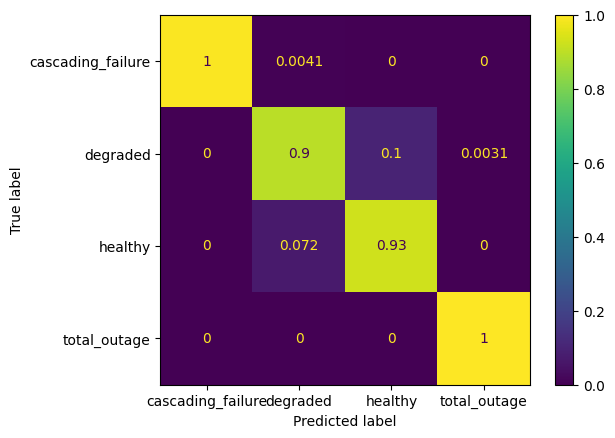

In [15]:
# fit
lda_pipeline.fit(X_train, y_train)

# redictions
lda_y_pred = lda_pipeline.predict(X_test)
lda_y_prob = lda_pipeline.predict_proba(X_test) 

# accuracy
print("Test accuracy:", lda_pipeline.score(X_test, y_test))

# classification report
print(classification_report(y_test, lda_y_pred))

# ROC AUC
roc_auc = roc_auc_score(y_test, lda_y_prob, multi_class="ovr", average="macro")
print("Test ROC AUC:", roc_auc)

cv_scores = cross_val_score(lda_pipeline, X_train, y_train, cv=5)
print("CV accuracy:", cv_scores.mean())

cv_auc = cross_val_score(
    lda_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc_ovr"
)
print("CV ROC AUC:", cv_auc.mean())

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lda_y_pred,
    normalize="true" 
)


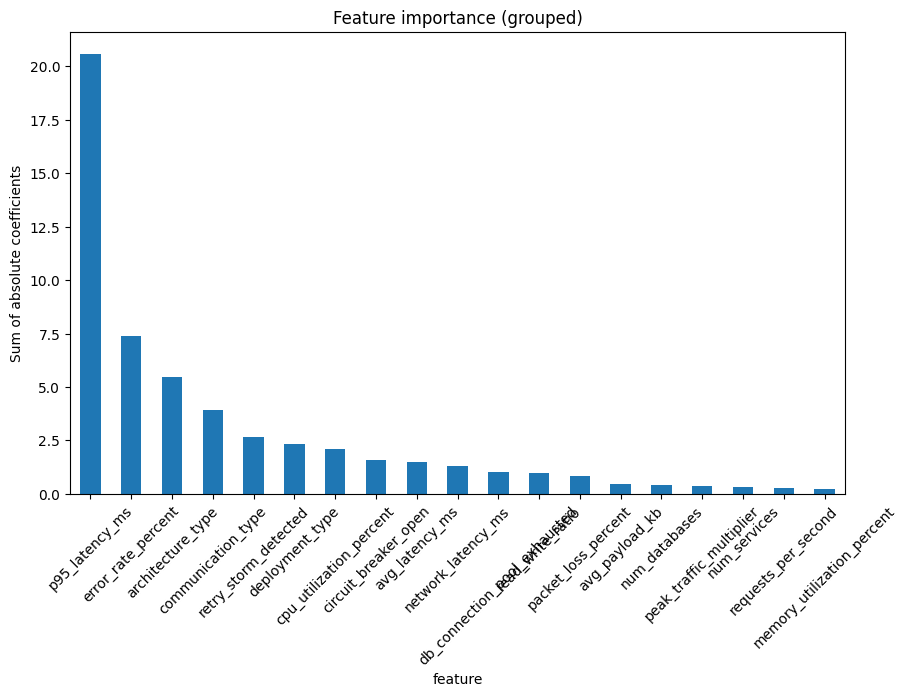

feature
p95_latency_ms                  20.584406
error_rate_percent               7.403240
architecture_type                5.461954
communication_type               3.942016
retry_storm_detected             2.648608
deployment_type                  2.347675
cpu_utilization_percent          2.121092
circuit_breaker_open             1.599142
avg_latency_ms                   1.482769
network_latency_ms               1.301003
db_connection_pool_exhausted     1.008698
read_write_ratio                 0.986090
packet_loss_percent              0.820699
avg_payload_kb                   0.445166
num_databases                    0.413515
peak_traffic_multiplier          0.358609
num_services                     0.341362
requests_per_second              0.291983
memory_utilization_percent       0.253527
Name: coef_abs, dtype: float64


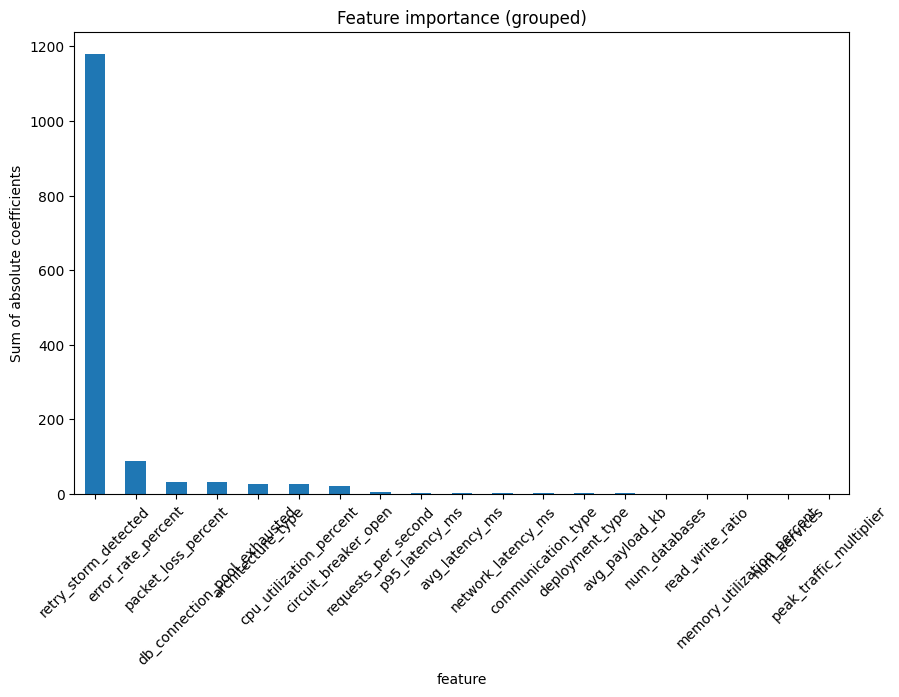

feature
retry_storm_detected            1179.992102
error_rate_percent                87.630045
packet_loss_percent               32.623866
db_connection_pool_exhausted      30.794363
architecture_type                 27.019251
cpu_utilization_percent           25.541676
circuit_breaker_open              20.008716
requests_per_second                6.140863
p95_latency_ms                     2.475366
avg_latency_ms                     2.377628
network_latency_ms                 2.019092
communication_type                 1.690563
deployment_type                    1.490257
avg_payload_kb                     1.401748
num_databases                      0.569573
read_write_ratio                   0.518768
memory_utilization_percent         0.455319
num_services                       0.280719
peak_traffic_multiplier            0.232617
Name: coef_abs, dtype: float64


In [ ]:
def plot_feature_importance(pipeline, X_train, categorical_cols, model_name="model"):
    
    model = pipeline.named_steps[model_name]
    preprocessor = pipeline.named_steps["prep"]
    
    encoder = preprocessor.named_transformers_["cat"]
    cat_features = encoder.get_feature_names_out(categorical_cols)
    num_features = X_train.columns.drop(categorical_cols)
    
    all_features = list(num_features) + list(cat_features)
    
    if len(model.coef_.shape) == 2:  # multiclass
        coefs = np.max(np.abs(model.coef_), axis=0)
    else:
        coefs = np.abs(model.coef_)
    
    coef_df = pd.DataFrame({
        "feature_full": all_features,
        "coef_abs": coefs
    })
    
    def map_original_feature(f):
        for cat in categorical_cols:
            if f.startswith(cat + "_"):
                return cat
        return f
    
    coef_df["feature"] = coef_df["feature_full"].apply(map_original_feature)
    
    grouped = coef_df.groupby("feature")["coef_abs"].sum().sort_values(ascending=False)
    
    plt.figure(figsize=(10,6))
    grouped.plot(kind="bar")
    plt.ylabel("Sum of absolute coefficients")
    plt.title("Feature importance (grouped)")
    plt.xticks(rotation=45)
    plt.show()
    
    return grouped

importance = plot_feature_importance(basic_pipeline, X_train, categorical_cols, model_name="model")
print(importance)

importance = plot_feature_importance(lda_pipeline, X_train, categorical_cols, model_name="model")
print(importance)

In [ ]:
qda_pipeline = Pipeline([
    ("prep", preprocess),  # preprocess as before (scaling optional)
    ("qda", QuadraticDiscriminantAnalysis(reg_param=0.1)) # get around collinearity of one hot variables
])

qda_pipeline.fit(X_train, y_train)

y_pred = qda_pipeline.predict(X_test)
y_prob = qda_pipeline.predict_proba(X_test)

print("QDA Test Accuracy:", qda_pipeline.score(X_test, y_test))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
print("QDA Test ROC AUC:", roc_auc)

QDA Test Accuracy: 0.819175
[[  245     0     0     0]
 [   32 13650  6980    31]
 [    0   190 18866     0]
 [    0     0     0     6]]
                   precision    recall  f1-score   support

cascading_failure       0.88      1.00      0.94       245
         degraded       0.99      0.66      0.79     20693
          healthy       0.73      0.99      0.84     19056
     total_outage       0.16      1.00      0.28         6

         accuracy                           0.82     40000
        macro avg       0.69      0.91      0.71     40000
     weighted avg       0.86      0.82      0.82     40000

QDA Test ROC AUC: 0.9823736673818749


In [ ]:

knn_pipeline = Pipeline([
    ("prep", preprocess),  # scale + one-hot as before
    ("knn", KNeighborsClassifier(n_neighbors=5))  # tune k later
])

knn_pipeline.fit(X_train, y_train)

y_pred = knn_pipeline.predict(X_test)
y_prob = knn_pipeline.predict_proba(X_test)

print("KNN Test Accuracy:", knn_pipeline.score(X_test, y_test))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")
print("KNN Test ROC AUC:", roc_auc)

KNN Test Accuracy: 0.893125
[[  244     1     0     0]
 [    0 18304  2389     0]
 [    0  1880 17176     0]
 [    0     5     0     1]]
                   precision    recall  f1-score   support

cascading_failure       1.00      1.00      1.00       245
         degraded       0.91      0.88      0.90     20693
          healthy       0.88      0.90      0.89     19056
     total_outage       1.00      0.17      0.29         6

         accuracy                           0.89     40000
        macro avg       0.95      0.74      0.77     40000
     weighted avg       0.89      0.89      0.89     40000

KNN Test ROC AUC: 0.9579272991654683


In [ ]:
# remove late stage indicators
cols_to_drop = [
    "db_connection_pool_exhausted",
    "retry_storm_detected",
    "circuit_breaker_open"
]

X_train_new = X_train.drop(columns=cols_to_drop)
X_test_new = X_test.drop(columns=cols_to_drop)

categorical_cols = ["architecture_type", "deployment_type", "communication_type"]
numerical_cols = X_train_new.columns.drop(categorical_cols)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
])

new_lr_pipeline = Pipeline([
    ("prep", preprocess),
    ("lr", LogisticRegression(max_iter=1000))
])

new_lr_pipeline.fit(X_train_new, y_train)

accuracy = new_lr_pipeline.score(X_test_new, y_test)
print("Logistic Regression Test Accuracy:", accuracy)

Logistic Regression Test Accuracy: 0.988325


In [20]:
# try to predict root_cause
# only look at root_cause
y_train = y_train_df["root_cause"]
y_test = y_test_df["root_cause"]

In [21]:
# make sure that its still distributed evenly because only stratified on system_state
print("Train distribution (%):")
print(y_train_df["root_cause"].value_counts(normalize=True))

print("\nTest distribution (%):")
print(y_test_df["root_cause"].value_counts(normalize=True))

Train distribution (%):
root_cause
none                          0.986869
network_partition             0.006537
service_dependency_failure    0.003906
cpu_saturation                0.002431
database_lock                 0.000256
Name: proportion, dtype: float64

Test distribution (%):
root_cause
none                          0.987475
network_partition             0.006550
service_dependency_failure    0.003725
cpu_saturation                0.002125
database_lock                 0.000125
Name: proportion, dtype: float64


In [22]:
train_mask = y_train_df["system_state"] != "healthy"

X_train_filtered = X_train[train_mask]
y_train_filtered = y_train_df.loc[train_mask, "root_cause"]

test_mask = y_test_df["system_state"] != "healthy"

X_test_filtered = X_test[test_mask]
y_test_filtered = y_test_df.loc[test_mask, "root_cause"]

In [ ]:

basic_pipeline.fit(X_train_filtered, y_train_filtered)

y_pred = basic_pipeline.predict(X_test_filtered)

accuracy = basic_pipeline.score(X_test_filtered, y_test_filtered)
print("Root Cause Test Accuracy:", accuracy)

cv_scores = cross_val_score(basic_pipeline, X_train_filtered, y_train_filtered, cv=5)
print("Root Cause CV mean:", cv_scores.mean())

y_prob = basic_pipeline.predict_proba(X_test_filtered)

roc_auc = roc_auc_score(
    y_test_filtered,
    y_prob,
    multi_class="ovr",
    average="macro"
)

print("Root Cause ROC AUC:", roc_auc)

Root Cause Test Accuracy: 0.997803666921314
Root Cause CV mean: 0.9968249081966318
Root Cause ROC AUC: 0.9999791791177575


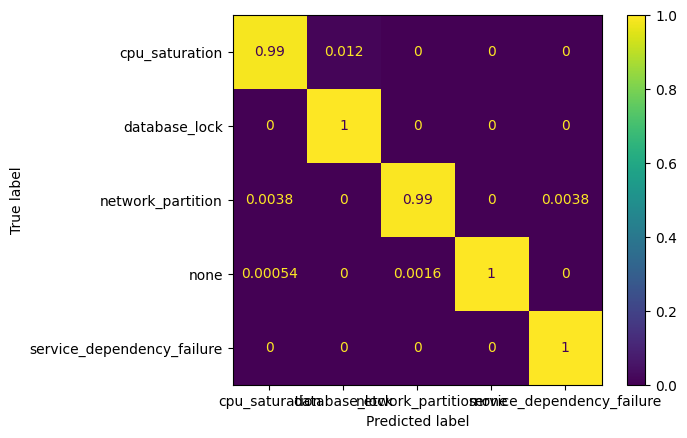

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_test_filtered,
    y_pred,
    normalize="true" 
)